In [59]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhrubangtalukdar/cybersecurity-threat-detection-dataset")

print("Path to dataset files:", path)

c:\Users\SRINITHIJA\anaconda3\envs\datascience\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 386k/386k [00:01<00:00, 260kB/s]

Extracting files...
Path to dataset files: C:\Users\SRINITHIJA\.cache\kagglehub\datasets\dhrubangtalukdar\cybersecurity-threat-detection-dataset\versions\3


In [4]:
import os

print("Dataset path:", path)
print(os.listdir(path))

Dataset path: C:\Users\SRINITHIJA\.cache\kagglehub\datasets\dhrubangtalukdar\cybersecurity-threat-detection-dataset\versions\3
['cybersecurity.csv']


In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

In [9]:
import os

print("Dataset path:", path)
print("Files inside folder:")
print(os.listdir(path))

Dataset path: C:\Users\SRINITHIJA\.cache\kagglehub\datasets\dhrubangtalukdar\cybersecurity-threat-detection-dataset\versions\3
Files inside folder:
['cybersecurity.csv']


In [10]:
file_path = os.path.join(path, "cybersecurity.csv")
data = pd.read_csv(file_path)

print(data.head())
print(data.shape)

             timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Windows NT 10.0; Win64; x6

In [11]:
print(data.isnull().sum())

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [12]:
data = data.dropna()

In [13]:
print(data.isnull().sum())

timestamp              0
src_ip                 0
dst_ip                 0
src_port               0
dst_port               0
protocol               0
bytes_sent             0
bytes_received         0
user_agent             0
url                    0
is_internal_traffic    0
label                  0
attack_type            0
dtype: int64


In [49]:
selected_features = [
    "src_port",
    "dst_port",
    "protocol",
    "bytes_sent",
    "bytes_received",
    "is_internal_traffic"
]

X = data[selected_features]
y = data["label"]

In [43]:
print(X.head())

   src_port  dst_port protocol  bytes_sent  bytes_received  \
0     56377       445      TCP        8029           17204   
1     51165      1433      TCP      676368         2643374   
3     36097       443      TCP       70933           21935   
4       445     21255      TCP       12721            9939   
6     25167       443      TCP        3592            1081   

   is_internal_traffic  
0                False  
1                False  
3                False  
4                False  
6                 True  


In [18]:
print(y.head())

0    0
1    0
3    0
4    0
6    0
Name: label, dtype: int64


In [45]:
print(X.head)

<bound method NDFrame.head of       src_port  dst_port protocol  bytes_sent  bytes_received  \
0        56377       445      TCP        8029           17204   
1        51165      1433      TCP      676368         2643374   
3        36097       443      TCP       70933           21935   
4          445     21255      TCP       12721            9939   
6        25167       443      TCP        3592            1081   
...        ...       ...      ...         ...             ...   
9993     44655      3306      TCP      102224          161909   
9994      3306        22      UDP      244511          280085   
9996      3389       445      TCP       10597           16670   
9998     31882        80      TCP        6062            3504   
9999     52607      3389      TCP      335446          442720   

      is_internal_traffic  
0                   False  
1                   False  
3                   False  
4                   False  
6                    True  
...                  

In [46]:
print(X.columns)

Index(['src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received',
       'is_internal_traffic'],
      dtype='object')


In [50]:
X = pd.get_dummies(X, columns=["protocol", "is_internal_traffic"])

In [51]:
print(X.head())

   src_port  dst_port  bytes_sent  bytes_received  protocol_ICMP  \
0     56377       445        8029           17204          False   
1     51165      1433      676368         2643374          False   
3     36097       443       70933           21935          False   
4       445     21255       12721            9939          False   
6     25167       443        3592            1081          False   

   protocol_TCP  protocol_UDP  is_internal_traffic_False  \
0          True         False                       True   
1          True         False                       True   
3          True         False                       True   
4          True         False                       True   
6          True         False                      False   

   is_internal_traffic_True  
0                     False  
1                     False  
3                     False  
4                     False  
6                      True  


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [54]:
y_pred = model.predict(X_test)

In [55]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9039881831610044

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1314
           1       0.15      0.47      0.23        40

    accuracy                           0.90      1354
   macro avg       0.57      0.70      0.59      1354
weighted avg       0.96      0.90      0.93      1354



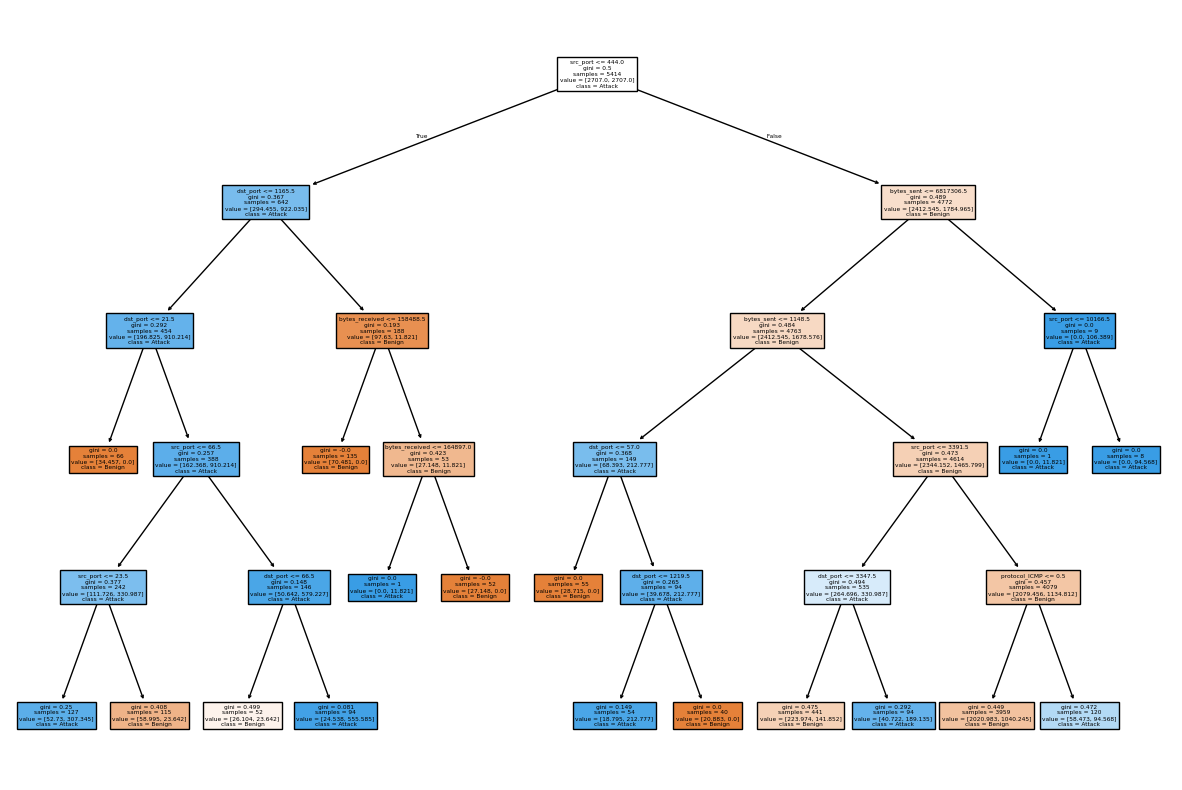

In [56]:
plt.figure(figsize=(15,10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Benign", "Attack"],
    filled=True
)
plt.show()

In [57]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

src_port                     0.390583
dst_port                     0.371263
bytes_sent                   0.182947
protocol_ICMP                0.028526
bytes_received               0.026681
protocol_TCP                 0.000000
protocol_UDP                 0.000000
is_internal_traffic_False    0.000000
is_internal_traffic_True     0.000000
dtype: float64


In [58]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [60]:
print(data["label"].value_counts())

label
0    6499
1     269
Name: count, dtype: int64


In [61]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1205  109]
 [  21   19]]
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1314
           1       0.15      0.47      0.23        40

    accuracy                           0.90      1354
   macro avg       0.57      0.70      0.59      1354
weighted avg       0.96      0.90      0.93      1354



In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
# ----------------------------
# Train Random Forest
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [64]:
from sklearn.metrics import accuracy_score

dt_pred = model.predict(X)
rf_pred = rf_model.predict(X)

print("Decision Tree Accuracy:", accuracy_score(y, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y, rf_pred))

Decision Tree Accuracy: 0.9101654846335697
Random Forest Accuracy: 0.9818262411347518


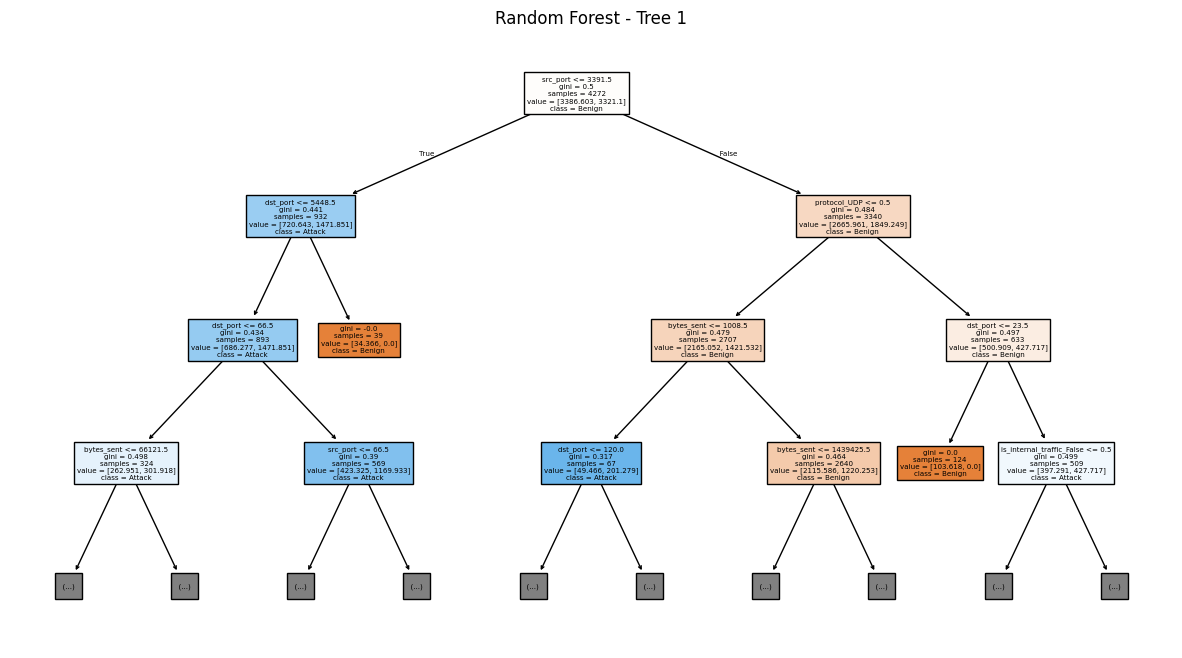

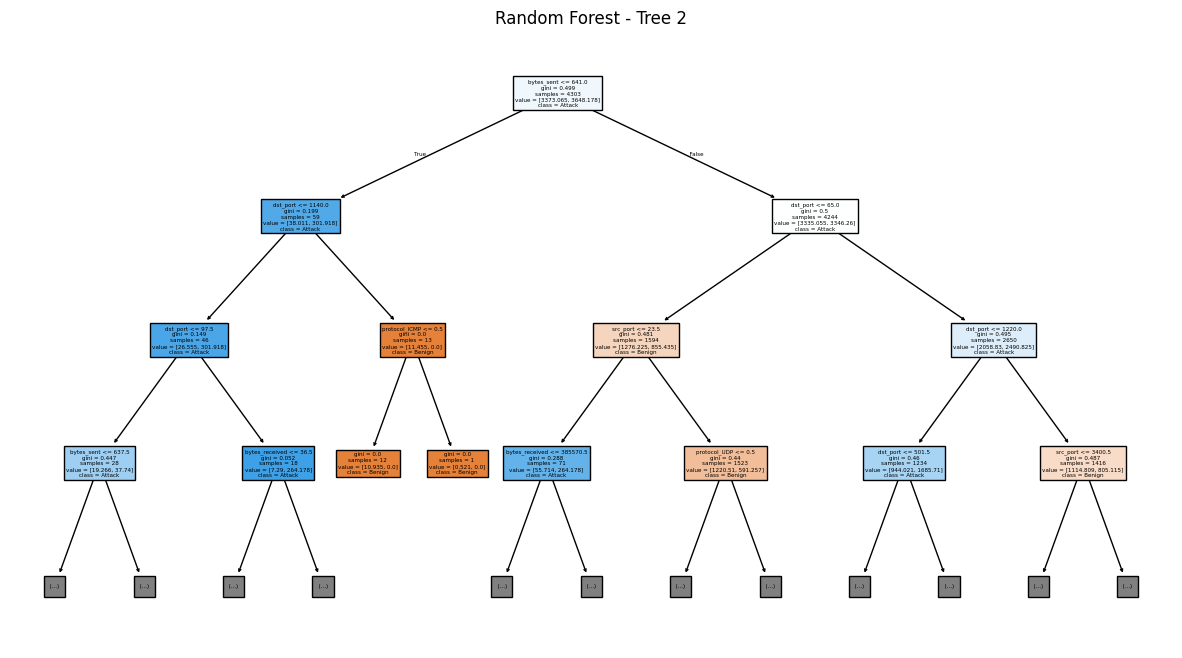

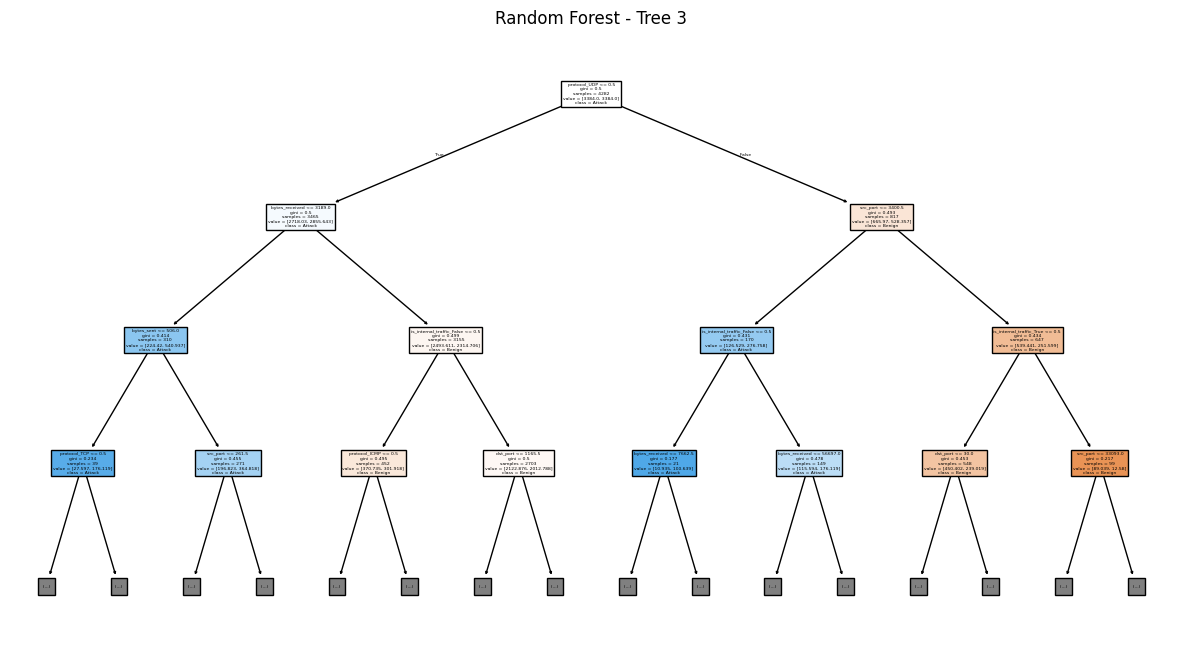

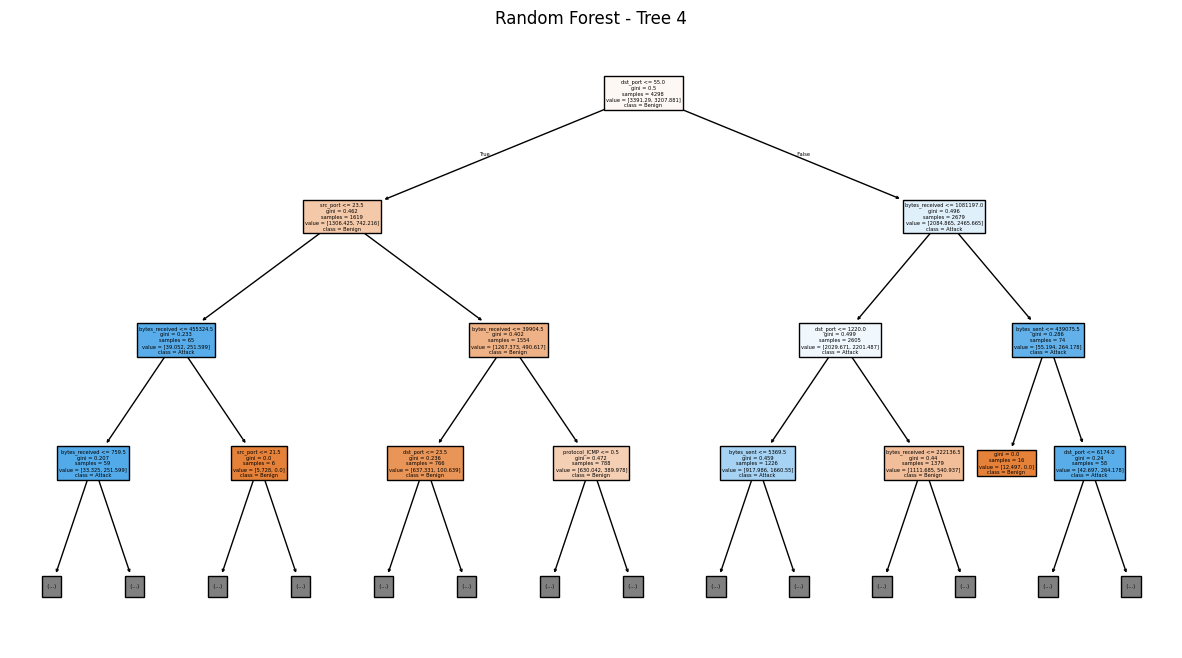

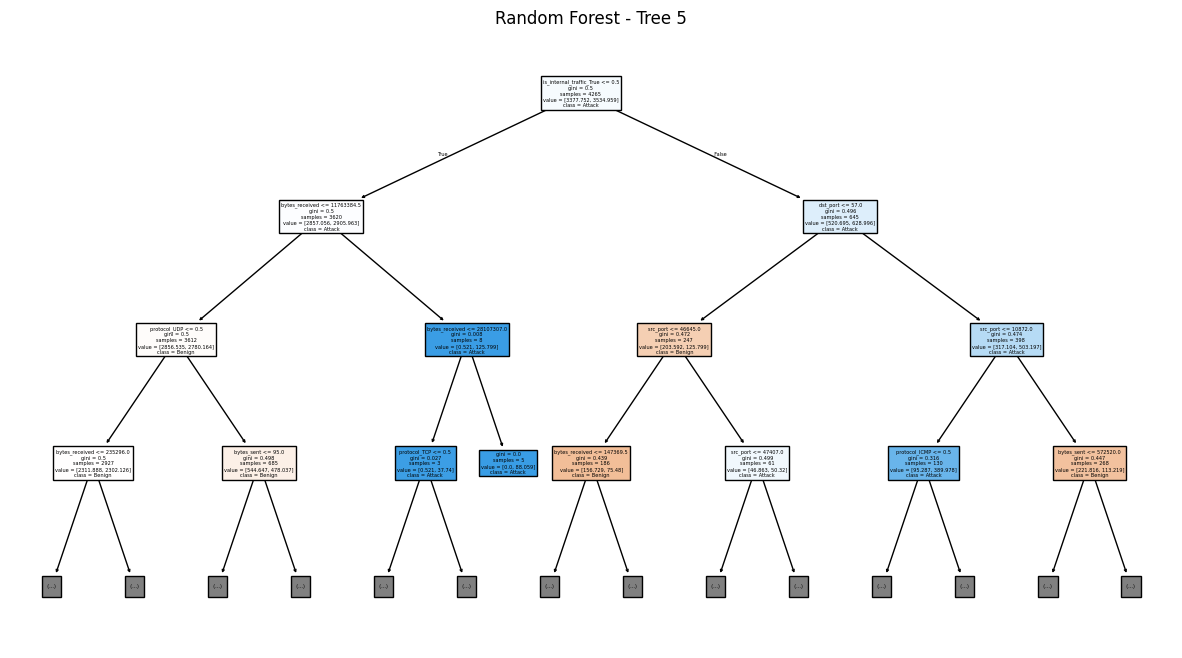

In [65]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot first 5 trees
for i in range(5):
    plt.figure(figsize=(15,8))
    plot_tree(
        rf_model.estimators_[i],   # ith tree
        feature_names=X.columns,
        class_names=["Benign", "Attack"],
        filled=True,
        max_depth=3   # limit depth for clarity
    )
    plt.title(f"Random Forest - Tree {i+1}")
    plt.show()